# Pneumonia Detection

## Preparing Data


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import pathlib as Path
import os

In [38]:
gpu = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# verify if GPU parallel calculus is possible
if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [39]:
import shutil
import kagglehub

dataset_url = "paultimothymooney/chest-xray-pneumonia"
LOCAL_DIR = "chest_xray/chest_xray"
KAGGLE_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray" #kaggle directory for training
DATA_DIR = ""

def load_data():
    """
    Load original pneumonia images data from the Kaggle's dataset. 
    """
    # if it finds the data does nothing otherwise it installs it --> cannot pass the dataset to Github for dimension limitations
    if os.path.exists(KAGGLE_DIR):
        print(f"Kaggle data in: {KAGGLE_DIR}")
        return KAGGLE_DIR
    elif os.path.exists(LOCAL_DIR):
        print(f"Local data in: {LOCAL_DIR}")
        return LOCAL_DIR
    else:
        # Download latest version --> kagglehub stores the dataset in a sort of cached memory so you need to copy it in local
        path = kagglehub.dataset_download(dataset_url)
        
        #shutil.copytree(path, ".", dirs_exist_ok=True)

        print("Path to dataset files:", path)
    return DATA_DIR
        
DATA_DIR = load_data()
print(DATA_DIR) 

Local data in: chest_xray/chest_xray
chest_xray/chest_xray


### Defining Trasformations

In [40]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset, Dataset

RESIZE_IMG = (128, 128) # resize img from (224,224) -> (128, 128)
datasets_names = ["train", "val", "test"]

# Define data augmentations
data_augmentations = [
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2), #setted to 20% as the paper suggest
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1))
]

# we create a set of transformations -> operations that will be applied to each img of the dataset for preprocessing
train_transform = transforms.Compose([
    transforms.Resize(RESIZE_IMG), # resizes the image to the desired dimension
    *data_augmentations,
    transforms.Grayscale(num_output_channels=3), # the paper uses three channels for these images
    transforms.ToTensor(), # convert all the values from range [0, 255] -> [0, 1]
    transforms.Normalize([0.485, 0.456, 0.406], # Standard ImageNet normalization
                         [0.229, 0.224, 0.225]) 
])


# Transform wihtout augmentations for test
base_transform = transforms.Compose([
    transforms.Resize(RESIZE_IMG),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# class created to apply the right transformation for each dataset
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y



### Loading Data

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, TensorDataset

# Load data: train val and 
train_folder = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
val_folder = datasets.ImageFolder(os.path.join(DATA_DIR, "val"))
test_folder = datasets.ImageFolder(os.path.join(DATA_DIR, "test"))

# Combine all datasets into one
full_dataset = ConcatDataset([train_folder, val_folder, test_folder])

print(f"Total images: {len(full_dataset)}")

# Extract all labels to stratify the split
all_targets = []
for ds in full_dataset.datasets:
    all_targets.extend(ds.targets)

all_targets = np.array(all_targets)

train_idx, test_idx = train_test_split(
    np.arange(len(all_targets)),
    test_size=0.2,
    shuffle=True,
    stratify=all_targets,
    random_state=42
)

# Split using stratified indices
train_dataset = Subset(full_dataset, train_idx)
test_dataset = Subset(full_dataset, test_idx)

# Create dictionary with train and test
image_datasets = {
    "train": train_dataset,
    "test": test_dataset
}

datasets_names = ["train", "test"]
class_names = train_folder.classes
print(class_names)
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Total images: 5856
['NORMAL', 'PNEUMONIA']
Train: 4684 | Test: 1172


### Applying transformations

In [ ]:
BATCH_SIZE = 32

# Apply transforms to the in-memory splits
# Apply to the splitted subsets the right transforms
image_datasets["train"] = TransformSubset(train_dataset, base_transform)
image_datasets["test"] = TransformSubset(test_dataset, base_transform)

# Create dataloaders with transforms already applied
dataloaders = {
    "train": DataLoader(image_datasets["train"], batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
    "test": DataLoader(image_datasets["test"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
}

# we access images in batches with an iterator
batch_images, batch_labels = next(iter(dataloaders["train"]))

print(batch_images.shape) # prints [batches, channels, width, heigth]
print(len(batch_images))

torch.Size([32, 3, 128, 128])
32


In [ ]:

def augmented_dataset(dataset_raw, transform_original, transform_aug, seed=42, target_count=None, device='cuda'):
    """
    INPUTS:
        - dataset_raw: original dataset
        - transform_original: base transform (resize, normalize, etc)
        - transform_aug: augmentation transform (flips, jitter, affine)
        - seed: random seed
        - target_count: target samples per class (default: max class)
        - device: 'cpu' or 'cuda'
    
    OUTPUTS:
        - TensorDataset with (images_tensors, labels_tensor)
    """

    # Extract labels 
    if hasattr(dataset_raw, 'dataset') and hasattr(dataset_raw.dataset, 'targets'):
        labels = [dataset_raw.dataset.targets[i] for i in dataset_raw.indices]
    else:
        labels = [dataset_raw[i][1] for i in range(len(dataset_raw))]
    
    labels = np.array(labels)
    
    # for each class attach the indices refering to that class
    class_indices = {}
    for idx, label in enumerate(labels):
        class_indices.setdefault(label, []).append(idx)
    
    # if not specified, the target count for oversampling is the class with more elements
    if target_count is None:
        target_count = max(len(idxs) for idxs in class_indices.values())
    
    rng = np.random.default_rng(seed) # random number generator to choose what images to augument
    
    tensors = []
    labels = []
    added_per_class = {label: 0 for label in class_indices.keys()}
    class_name_map = {}
    if hasattr(dataset_raw, 'dataset') and hasattr(dataset_raw.dataset, 'classes'):
        class_name_map = {i: name for i, name in enumerate(dataset_raw.dataset.classes)}
    elif hasattr(dataset_raw, 'classes'):
        class_name_map = {i: name for i, name in enumerate(dataset_raw.classes)}
    
    # Add original images with base transformations
    for i in range(len(dataset_raw)):
        img, label = dataset_raw[i]
        img_tensor = transform_original(img)
        tensors.append(img_tensor)
        labels.append(label)
    
    # Add augmented images
    for label, idxs in class_indices.items():
        n_needed = target_count - len(idxs) #images needed are the target count - the images we alreade have
        if n_needed <= 0:
            continue
        chosen = rng.choice(idxs, size=n_needed, replace=True) #choose n_needed sample to generate from the idxs of the current class
        for src_idx in chosen:
            img, _ = dataset_raw[src_idx] #choos an image
            img_tensor = transform_aug(img) if transform_aug else transform_original(img) #trasform the image
            tensors.append(img_tensor) #append the transformed image into the aug_tensors list
            labels.append(label)
            added_per_class[label] += 1
    
    # Stack all into single tensors
    images_tensor = torch.stack(tensors, dim=0)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    
    total_added = len(tensors) - len(dataset_raw)
    print(f"Original: {len(dataset_raw)} | Augmented: {total_added}")
    for label in sorted(added_per_class.keys()):
        class_name = class_name_map.get(int(label), str(label))
        print(f"Added class {label} ({class_name}): {added_per_class[label]}")
    
    return TensorDataset(images_tensor, labels_tensor)

## CNN Feature Extractor

The following pipeline is a **Convolutional Neural Network Feature Extractor** built to process images and compress them.

We can see two different phases:

# 1. Spatial Feature Extractor

It consists of three repeating "Convolutional Blocks." The goal here is to learn visual patterns while reducing image dimension and increasing information density.
In particular, we apply the following blocks for 3 times:
- **Conv2D**: scans the images for features;
- **BatchNorm2D**: Normalizes values;
- **Leaky ReLU**: activation function;
- **MaxPooling**: reduces dimensions taking the highest value in a batch;

# 2. Flattening and Projection

Once the spatial features are extracted, the pipeline prepares the data for the BiGRU.

In particular we used:
- `Flatten()`: takes the (channel, width, height) tensor and creates a 1D vector;
- `Linear()`: compresses the massive flattened vector into a smaller dimension (performed two times).

In [45]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, (3, 3), padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, (3, 3), padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 

            nn.Conv2d(64, 128, (3, 3), padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.1, inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(), 
            
            # 32768 implies our input images are 128x128.
            nn.Linear(32768, 128),
            nn.Linear(128, 64) # Output size is 64
        )
        
    def forward(self, x):
        return self.cnn(x)

print(batch_images.shape) # print again the tensor shape
cnn = CNN()

torch.Size([32, 3, 128, 128])


# About performing the linear projection

We decided to perform linear projection of data into a smaller space *BEFORE* defining the GRU block. In the paper it is not clearly specified which input to pass the **Gated Recurrent Unit**, but working with a smaller dataset shows a much better performance and a better computational time. 

# Gated Recurrent Unit (GRU) & BiGRU

**Introduction to BiGRU**
**Recurrent Neural Networks (RNNs)** are designed to handle sequential data by maintaining a hidden state that captures information from previous time steps.
The **Bidirectional Gated Recurrent Unit (BiGRU)** is an enhancement of the standard GRU. While a standard RNN processes sequences only from start to end, a BiGRU processes data in both directions. This allows the network to capture context from both sides of a specific time step. In the context of this project, the block utilizes 2 stacked layers with a hidden size of 256.

### Mathematical Formulation

The GRU addresses the vanishing gradient problem found in traditional RNNs using gating mechanisms.

**1. Update Gate ($z_t$)**
The update gate determines how much of the past hidden state should be retained. It helps the model decide what information to carry forward.

$$
z_t = \sigma (W_z x_t + U_z h_{t-1} + b_z)
$$

* $W_z, U_z$: Weight matrices.
* $b_z$: Bias vector.
* $\sigma$: Sigmoid activation function (outputs values between 0 and 1).

**2. Reset Gate ($r_t$)**
The reset gate controls how much of the previous hidden state is forgotten, allowing the model to drop irrelevant information.

$$
r_t = \sigma (W_r x_t + U_r h_{t-1} + b_r)
$$

* $W_r, U_r, b_r$: Corresponding weights and bias for the reset gate.

**3. Candidate Hidden State ($\tilde{h}_t$)**
The candidate hidden state is computed using the reset gate to modulate the influence of the previous hidden state.

$$
\tilde{h}_t = \tanh (W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)
$$

* $\odot$: Element-wise multiplication (Hadamard product).
* $r_t$: The reset gate value acts as a filter on $h_{t-1}$.

In [ ]:
num_steps = 25

class BiGRU(nn.Module):
    def __init__(self, num_steps, input_size=64, hidden_size=256, dropout=0.3, activation = True):
        super().__init__()
        
        self.num_steps = num_steps
        self.bigru = nn.GRU(
                    input_size=input_size,
                    hidden_size=hidden_size,
                    num_layers=2,
                    dropout=dropout,
                    bidirectional=True,
                    batch_first=True
        )
        self.activation = activation
        self.m = nn.Linear(64, 512)
        
    def forward(self, x):
        """
            x: Input tensor of shape [batch_size, input_size]
            Returns an output tensor of shape (batch_size, num_steps, hidden_size * 2)
            
            If activation parameter is not set the application of the BiGRU will be skipped.
            Implemented just for testing purpose since the paper confronts the BiGRU with non-BiGRU results.
        """
        x_seq = x.unsqueeze(1).repeat(1, self.num_steps, 1) # repeat the sample for num_steps times
        
        # if in training we add noise to simulate the variation over time of the images.
        if self.training: # parameter of the nn.Module
            noise = torch.randn_like(x_seq) * 0.02 # generates gaussian noise to add to the time steps (not statical anymore).
            x_seq = x_seq + noise
        
        if self.activation:
            # out shape: (batch_size, num_steps, hidden_size * 2)
            out, _ = self.bigru(x_seq)
        else:
            out = self.m(x_seq) # in order to be coherent with the output of the BiGRU
        
        return out


In [ ]:
class Reshape(nn.Module):
    """
        Reshaping class just to reset BiGRU output so that it stays in a predefined range
        DEFAULT: (-1.0, 1.0)
    """
    def __init__(self, value = 1.0):
        super().__init__()
        
        self.max_value = value
        self.min_value = -value
        self.epsilon = 1.e-8
    
    def forward(self, x):
        # here we have an x which is the output of the BiGRU so a tensor [32, 25, 512]
        max_value = x.max()        
        min_value = x.min()
        
        # define the parameter of reshaping so the range of values goes from [self.min_value, self.max_value]
        std = (x - min_value) / (max_value - min_value + self.epsilon)
        x_scaled = std*(self.max_value - self.min_value) + self.min_value
        
        return x_scaled     

### Spiking Neural Network (SNN)

Unlike traditional neural networks that transmit continuous values, Spiking Neural Networks communicate via discrete *spikes*. The functioning is governed by the temporal dynamics of a neuron's membrane potential.

### 1. Integration and Leakage
The most common model, the **Leaky Integrate-and-Fire (LIF)** used in our implementation, describes the membrane potential ($V$) of a neuron over time ($t$). The potential increases as it receives input (integration) but naturally decays toward a resting state over time (leakage):

$$\tau_m \frac{dV(t)}{dt} = -V(t) + I(t)$$

* **$\tau_m$**: Membrane time constant.
* **$V(t)$**: Current membrane potential.
* **$I(t)$**: Input current (from the BiGRU in our case).

### 2. Threshold and Spiking
A spike is generated at time $t$ if the membrane potential reaches a specific threshold $V_{th}$:

$$S(t) = \begin{cases} 1.5 & \text{if } V(t) \geq V_{th} \\ 0 & \text{otherwise} \end{cases}$$

### 3. Reset Mechanism
Immediately after a spike is emitted ($S(t) = 1$), the membrane potential is "reset" to a lower value ($V_{reset}$).

### 4. Temporal Coding in our Project
In this hybrid model, the BiGRU's continuous output is partitioned into discrete **time steps**. The SNN layers process these steps sequentially.

In [ ]:
import snntorch as snn
from snntorch import surrogate

class DoubleSNN(nn.Module):
    def __init__(self, input_size=64, hidden_size=256):
        super().__init__()
        beta = 0.95 # setup value of beta (given in the paper)
        
        spike_grad = surrogate.fast_sigmoid(slope=25) # surrogate gradient will be used for backpropagation (used default value here)
        self.fc1 = nn.Linear(input_size, 256) # define the projection to 256 dimension
        self.lif1 = snn.Leaky(beta=beta, threshold=1.5, spike_grad=spike_grad, init_hidden=True, output=True)
        
        # si potrebbe modificare la treshold a 0.1 se quella impostata a 1 di default è troppo bassa
        concat_size = 768
        self.fc2 = nn.Linear(concat_size, concat_size)    
        self.lif2 = snn.Leaky(beta=beta, threshold=1.5, spike_grad=spike_grad, init_hidden=True, output=True) # returns mem and spk if output=True
        
    def forward(self, x, y): #y is the output from the feature projection after the cnn
        """
            Takes in input the tensor with the time_steps defined in the BiGRU layer.
        """
        self.lif1.reset_mem()
        self.lif2.reset_mem()
                
        spk_list = [] # snn results will be saved here 
        
        for step in range(num_steps):
            bigru_out = x[:, step, :] # because the bigru output is a tensor like [batch_size, num_steps, 512]
            
            cur1 = self.fc1(y)
            spk1, _ = self.lif1(cur1) # save the state that comes from the hidden membrane
            
            concat_input = torch.cat((spk1, bigru_out), dim=1) # concatenate the snn_input with the output of the feature projection after the cnn
            
            cur2 = self.fc2(concat_input)
            spk2, _ = self.lif2(cur2)
            
            """
            if self.training and torch.rand(1).item() < 0.001: 
                # Mean of 0s and 1s gives the exact percentage of active neurons
                firing_rate2 = spk2.float().mean().item() 
                print(f"[Diagnostics] SNN Firing Rate2: {firing_rate2 * 100:.2f}%")
            """
            spk_list.append(spk2) # store the spike output into a list
            
        # here we stack data along the num_steps dimension. Basically we take all the spk_output for each time step
        # and we put it in an array. In the end we perform spike mean aggregation along the time_step dimension.
        stacked_spk = torch.stack(spk_list, dim=1)
        return torch.mean(stacked_spk, dim=1)

# FullNet Architecture

The FullNet class is a unified wrapper that encapsulates the entire hybrid pipeline into a single nn.Module. It sequentially integrates the neural blocks defined previously:
- **CNN Block**: Extracts spatial features from 128×128 input images.
- **GRU Block**: Processes features temporally to capture dependencies.
- **SNN Block**: Simulates spiking neurons with surrogate gradients.
- **Decision Block**: Linearize the SNN output to a 'label_size' tensor.

**Forward Pass**: The forward method orchestrates the data flow through all blocks end-to-end, converting static images into temporal sequences and finally aggregating spike activity into raw logits for classification.

In [ ]:
# definition of the Net

class FullNet(nn.Module):
    def __init__(self, num_steps, bigru = True, reshaping = True):
        super().__init__()
        
        # initialize the layers defined as classes previously
        self.cnn = CNN()
        self.bigru = BiGRU(
            num_steps=num_steps,
            activation = bigru
        )
        self.reshape = None
        if reshaping:
            self.reshape = Reshape()
        self.snn = DoubleSNN()
        # define the decision head over here.
        self.decision_head = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        ) # initialize the layer which linearizes until [batch_size, num_labels] (2 labels in this case)
        
        
    def forward(self, x):
        """
            x : input of shape [batch_size, channels, img_width, img_heigth]
        """
        # apply all the input across all the layers
        y = self.cnn(x)
        x = self.bigru(y)
        if self.reshape:
            x = self.reshape(x)
        x = self.snn(x, y)
        
        logits = self.decision_head(x)
        
        return logits

### Define Hyperparameters for Training

In [50]:
import torch.optim as optim

# definition of some usefull parameters
TRAIN_EPOCHS = 30 # number of max training epochs
TARGET_EPOCHS = 7 # actual number of training epochs performed (at least this is said on the paper)

# define some parameters to pass the Adam optimizer
lr = 1e-5
w_decay = 1e-5

halving_param = 5 # training halves early if no improvement in 5 consecutive epochs (check paper)

# define the CrossEntropyLoss object. It expects raw logits as the ones given in output by the pipeline
# Applies SoftMax and computes the NLLL loss.
loss = nn.CrossEntropyLoss() 

### Metrics Computation and Confusion Matrix

The following functions are used to compute some metrics to evaluate the model performance:

- **Recall:** Measures the model's ability to find positive cases among all the possible pneumonia samples. 
- **Precision:** Measures the correctness of our positive predictions.
- **F1-Score:** The mean of Precision and Recall. It provides a single balanced score that is especially useful for evaluating models on datasets where one class is much larger than the other.
- **Accuracy:** Represents the overall percentage of correct predictions (both healthy and pneumonia) out of the total dataset.

In [51]:
def update_confusion_matrix(logits, batch_labels, results):
    """
    Updates the TP, TN, FP, FN counters in the 'stats' dictionary.
    INPUTS:
            - logits: used to compute predictions
            - batch_labels: used to compute metrics based on predictions
            - results: dictionary in which we accumulate some metrics
    """
    if hasattr(logits, 'cpu'): 
        logits = logits.cpu().detach().numpy()
    if hasattr(batch_labels, 'cpu'):
        batch_labels = batch_labels.cpu().detach().numpy()
    # Get predictions
    predictions = np.argmax(logits, axis=1)

    # Calculate overlaps using Bitwise AND (&)
    # Boolean arrays act as 0/1 integers when summed
    results['TP'] += ((predictions == 1) & (batch_labels == 1)).sum()
    results['TN'] += ((predictions == 0) & (batch_labels == 0)).sum()
    results['FP'] += ((predictions == 1) & (batch_labels == 0)).sum()
    results['FN'] += ((predictions == 0) & (batch_labels == 1)).sum()

def compute_metrics(results, metrics):
    """
        Compute some metrics relative to the paper.
        INPUT:
            - results: dictionary in which we accumulated results of confusion matrix
            - metrics: dictionary in which we store metrics
    """    
    TP = results["TP"]
    TN = results["TN"]
    
    FP = results["FP"]
    FN = results["FN"]
    
    epsilon = 1e-8 # added this to avoid division by zero.
    recall = TP / (TP + FN + epsilon)
    precision = TP / (TP + FP + epsilon)

    metrics["Recall"] = recall
    metrics["Precision"] = precision
    metrics["F1-Score"] = (2.0 * recall * precision) / (recall + precision + epsilon)
    metrics["Accuracy"] = (TN + TP) / (TP + FP + TN + FN + epsilon)
    

In [ ]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode
    
    total_loss = 0
    # initialize metrics dictionaries
    results = {
        'TP': 0, 
        'TN': 0,
        'FP': 0,
        'FN': 0
    }
    metrics = {}
    
    # No need of gradient computation in validation
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            
            # Pass the batch images in the model in a forward pass and compute the logits.
            logits = model(batch_images)

            loss_value = loss_fn(logits, batch_labels) # compare the logits with the actual labels of the model
            
            # Accumulate loss
            total_loss += loss_value.item()
            
            # Calculate accuracy
            update_confusion_matrix(logits, batch_labels, results)
    
    model.train()  # Set back to training mode
    avg_loss = total_loss / len(dataloader)

    compute_metrics(results, metrics)
    
    # return avarage loss and the accuracy
    return avg_loss, metrics, results


## K-Fold Cross-Validation

To ensure our pneumonia detection model truly generalizes to unseen data, we implement **$k$-Fold Cross-Validation**.

#### How It Works
Instead of splitting the data just once, we divide the entire training dataset into $k$ equal-sized partitions (or "folds"). 
In this case a value of `k = 5` is chosen and we create a *kfold* object from the KFold class of *sklearn*. 

1. **Split:** The full dataset is shuffled and divided into $k$ distinct subsets.
2. **Iterate:** The training process is repeated $k$ times. 
3. **Train & Validate:** In each iteration, one fold is held back as the validation set, while the model trains on the remaining $k-1$ folds.
4. **Average:** After $k$ iterations, every single fold has been used for validation exactly once. We then average the performance metrics across all $k$ runs to compute a final, highly reliable evaluation score.


In [ ]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset

k_folds = 5
count = 0

# Defining the k fold for cross-validation
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# we need to use the raw train dataset (without transforms) 
# to divide into folders for cross validation
full_train_dataset = train_dataset

results = [] # to save metrics of each fold validation
train_loss_history = np.zeros((k_folds, TRAIN_EPOCHS)) # define a matrix to store loss values of training
valid_loss_history = np.zeros((k_folds, TRAIN_EPOCHS)) # define a matrix to store loss values of validation
train_acc_history = np.zeros((k_folds, TRAIN_EPOCHS)) # define a matrix to store accuracy values of training
valid_acc_history = np.zeros((k_folds, TRAIN_EPOCHS)) # define a matrix to store accuracy values of validation

# iterating over folds
for fold, (train_idx, val_idx) in enumerate(kfold.split(full_train_dataset)):
    
    # subset for the current fold
    sub_train = Subset(full_train_dataset, train_idx)
    sub_val = Subset(full_train_dataset, val_idx)
    print(f"sub_train : {len(sub_train)} | sub_val : {len(sub_val)}")

    #sub_train_oversampled = augment_and_oversample(dataset_raw=sub_train,transform_original=base_transform,transform_aug = train_transform, seed=42)

    sub_train_oversampled = augmented_dataset(sub_train, base_transform, train_transform, target_count = 3000)
    
    # apply transformations to validation set
    sub_val_transformed = TransformSubset(sub_val, base_transform)
    
    # dataloaders for the current fold
    train_loader = DataLoader(sub_train_oversampled, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(sub_val_transformed, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # calculate steps per epoch (the size of the train set is changed)
    steps_per_epoch = len(train_loader)

    # we have to initialize the model every time to reset and don't corrupt the results
    model = FullNet(num_steps, reshaping=False) 
    model.to(device)

    # we have to initialize the optimizer and lr_scheduler every time to reset and don't corrupt the results
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=w_decay
    )

    # define the OneCycleLR scheduler
    lr_scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer=optimizer,
        max_lr=lr,
        epochs=TRAIN_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.1,
    )

    #reset best_loss, best_val_accuracy and count at each iteration on folds for the early stopping
    best_loss = float('inf')
    best_val_acc = 0.0  
    count = 0 # counts the number of non-improving epochs

    # start training of the current fold
    for epoch in range(TRAIN_EPOCHS):
        
        model.train()  # Set to training mode
        correct = 0
        samples = 0
        total_train_loss = 0
        
        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            
            # Forward pass
            logits = model(batch_images)
            loss_value = loss(logits, batch_labels)

            # Backward pass
            optimizer.zero_grad()
            loss_value.backward()

            # Update parameters through Adam and OneCycleLR
            optimizer.step()
            lr_scheduler.step()
            
            # some values computations for loss and accuracy for training
            total_train_loss += loss_value.item()
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == batch_labels).sum().item()
            samples += batch_labels.size(0) # Add batch size (e.g., 32)
            
        avg_loss_value = total_train_loss / len(train_loader) # save the avarage value of the epoch.
        avg_acc_value = correct / samples
        
        # Validation after each epoch of the current folder. Validation is performed for each epoch and for each of the folds.
        val_loss, metrics, _ = eval_model(model, val_loader, loss, device)
        val_acc = metrics["Accuracy"]
        
        train_loss_history[fold, epoch] = avg_loss_value
        valid_loss_history[fold, epoch] = val_loss
        train_acc_history[fold, epoch] = avg_acc_value
        valid_acc_history[fold, epoch] = val_acc
        
        print(f"Epoch {epoch+1}/{TRAIN_EPOCHS} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

        # Early stop criteria and implementation
        if val_loss < best_loss:
            best_loss = val_loss  # Update best loss
            best_val_acc = val_acc  
            count = 0  # Reset counter for consecutive epochs without improvements
        else: 
            count += 1

        if count >= halving_param:
            print(f"Early stopping: no improvement in validation loss for {halving_param} consecutive epochs")
            break
        
    results.append({"fold": fold, "val_loss": best_loss, "val_acc": best_val_acc * 100})
    print(f"Fold {fold + 1} completed: best loss {best_loss:.4f} | best acc {best_val_acc*100:.2f}%\n")
    
mean_train_loss = np.mean(train_loss_history, axis=0) # Compute the mean loss for each epoch
mean_val_loss = np.mean(valid_loss_history, axis=0)   # Basically the same but for validation
mean_train_acc = np.mean(train_acc_history, axis=0) 
mean_val_acc = np.mean(valid_acc_history, axis=0) 

#compute final mean loss and mean accuracy between the different folds to summarize the results of the k-fold cross validation training
mean_acc = sum(r["val_acc"] for r in results) / len(results)
mean_loss = sum(r["val_loss"] for r in results) / len(results)
print(f" mean loss: {mean_loss:.4f} | mean acc: {mean_acc:.2f}%")

sub_train : 3747 | sub_val : 937
Original: 3747 | Augmented: 1729
Epoch 1/30 | Val Loss: 0.6658 | Val Acc: 72.57%
Epoch 2/30 | Val Loss: 0.3899 | Val Acc: 94.34%
Epoch 3/30 | Val Loss: 0.1410 | Val Acc: 95.62%
Epoch 4/30 | Val Loss: 0.2283 | Val Acc: 92.00%
Epoch 5/30 | Val Loss: 0.1393 | Val Acc: 94.77%
Epoch 6/30 | Val Loss: 0.1252 | Val Acc: 95.84%
Epoch 7/30 | Val Loss: 0.1305 | Val Acc: 95.84%
Epoch 8/30 | Val Loss: 0.1331 | Val Acc: 95.94%
Epoch 9/30 | Val Loss: 0.1295 | Val Acc: 95.52%
Epoch 10/30 | Val Loss: 0.1470 | Val Acc: 95.94%
Epoch 11/30 | Val Loss: 0.2096 | Val Acc: 94.34%
Early stopping: no improvement in validation loss for 5 consecutive epochs

Fold 1 completed: best loss 0.1252 | best acc 95.84%
sub_train : 3747 | sub_val : 937
Original: 3747 | Augmented: 1681
Epoch 1/30 | Val Loss: 0.7009 | Val Acc: 24.87%
Epoch 2/30 | Val Loss: 0.3389 | Val Acc: 92.96%
Epoch 3/30 | Val Loss: 0.1166 | Val Acc: 95.84%
Epoch 4/30 | Val Loss: 0.1368 | Val Acc: 95.30%
Epoch 5/30 | Val 

## Training

In [ ]:
from torch.utils.data import TensorDataset

print(lr)
print(w_decay)

full_train_dataset = train_dataset

results = [] # to save metrics of each fold validation
train_loss_history = np.zeros(TRAIN_EPOCHS) # define a matrix to store loss values of training
valid_loss_history = np.zeros(TRAIN_EPOCHS) # define a matrix to store loss values of validation
train_acc_history = np.zeros(TRAIN_EPOCHS) # define a matrix to store accuracy values of training
valid_metrics_history = []

all_targets = []
# Extract all labels to stratify the split
all_targets = np.array([label for _, label in full_train_dataset])

train_idx, val_idx = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.2,
    shuffle=True,
    stratify=all_targets,
    random_state=42
)
    
# subsets for training and validation
sub_train = Subset(full_train_dataset, train_idx)
sub_val = Subset(full_train_dataset, val_idx)
print(f"sub_train : {len(sub_train)} | sub_val : {len(sub_val)}")

# apply some augmentation transformation to the training (these will not be applied to the validation set)
sub_train_oversampled = augmented_dataset(sub_train, base_transform, train_transform, target_count = 3000)

# apply transformations to validation set
sub_val_transformed = TransformSubset(sub_val, base_transform)

# dataloaders for the current fold
train_loader = DataLoader(sub_train_oversampled, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(sub_val_transformed, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# calculate steps per epoch (the size of the train set is changed)
steps_per_epoch = len(train_loader)

# we have to initialize the model every time to reset and don't corrupt the results
model = FullNet(num_steps, reshaping=False, bigru=True) 
model.to(device)

# we have to initialize the optimizer and lr_scheduler every time to reset and don't corrupt the results
optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=w_decay
)

# define the OneCycleLR scheduler
lr_scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer=optimizer,
    max_lr=lr,
    epochs=TRAIN_EPOCHS,
    steps_per_epoch=steps_per_epoch
)

#reset best_loss, best_val_accuracy and count at each iteration on folds for the early stopping
best_loss = float('inf')
best_val_acc = 0.0  
count = 0 # counts the number of non-improving epochs

# start training of the current fold
for epoch in range(TRAIN_EPOCHS):
    
    model.train()  # Set to training mode
    correct = 0
    samples = 0
    total_train_loss = 0
    
    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        logits = model(batch_images)
        loss_value = loss(logits, batch_labels)

        # Backward pass
        optimizer.zero_grad()
        loss_value.backward()

        # Update parameters through Adam and OneCycleLR
        optimizer.step()
        lr_scheduler.step()
        
        # some values computations for loss and accuracy for training
        total_train_loss += loss_value.item()
        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == batch_labels).sum().item()
        samples += batch_labels.size(0) # Add batch size (e.g., 32)
        
    avg_loss_value = total_train_loss / len(train_loader) # save the avarage value of the epoch.
    avg_acc_value = correct / samples
    
    # Validation after each epoch of the current folder
    val_loss, metrics, _ = eval_model(model, val_loader, loss, device)
    val_acc = metrics["Accuracy"]
    
    train_loss_history[epoch] = avg_loss_value
    valid_loss_history[epoch] = val_loss
    train_acc_history[epoch] = avg_acc_value
    valid_metrics_history.append(metrics)
    
    print(f"Epoch {epoch+1}/{TRAIN_EPOCHS} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    # Early stop criteria and implementation
    if val_loss < best_loss:
        best_loss = val_loss  # Update best loss
        best_val_acc = val_acc  
        count = 0  # Reset counter for consecutive epochs without improvements
    else: 
        count += 1

    if count >= halving_param:
        print(f"Early stopping: no improvement in validation loss for {halving_param} consecutive epochs")
        break

print(f"Completed: best loss {best_loss:.4f} | best acc {best_val_acc*100:.2f}%")

1e-05
1e-05
sub_train : 3747 | sub_val : 937
Original: 3747 | Augmented: 1721
Epoch 1/30 | Val Loss: 0.6804 | Val Acc: 73.00%
Epoch 2/30 | Val Loss: 0.6527 | Val Acc: 85.38%
Epoch 3/30 | Val Loss: 0.4694 | Val Acc: 90.72%
Epoch 4/30 | Val Loss: 0.2446 | Val Acc: 93.92%
Epoch 5/30 | Val Loss: 0.1487 | Val Acc: 95.30%
Epoch 6/30 | Val Loss: 0.1426 | Val Acc: 95.09%
Epoch 7/30 | Val Loss: 0.1289 | Val Acc: 95.52%
Epoch 8/30 | Val Loss: 0.1595 | Val Acc: 94.98%
Epoch 9/30 | Val Loss: 0.1436 | Val Acc: 95.41%
Epoch 10/30 | Val Loss: 0.1612 | Val Acc: 94.56%
Epoch 11/30 | Val Loss: 0.1323 | Val Acc: 95.73%
Epoch 12/30 | Val Loss: 0.1516 | Val Acc: 95.41%
Early stopping: no improvement in validation loss for 5 consecutive epochs
Completed: best loss 0.1289 | best acc 95.52%


## Testing


In [55]:
test_loss, metrics, confusion_m = eval_model(model, dataloaders["test"], loss, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {metrics["Accuracy"]*100:.2f}%")

Test Loss: 0.1891 | Test Acc: 94.97%


## Metrics

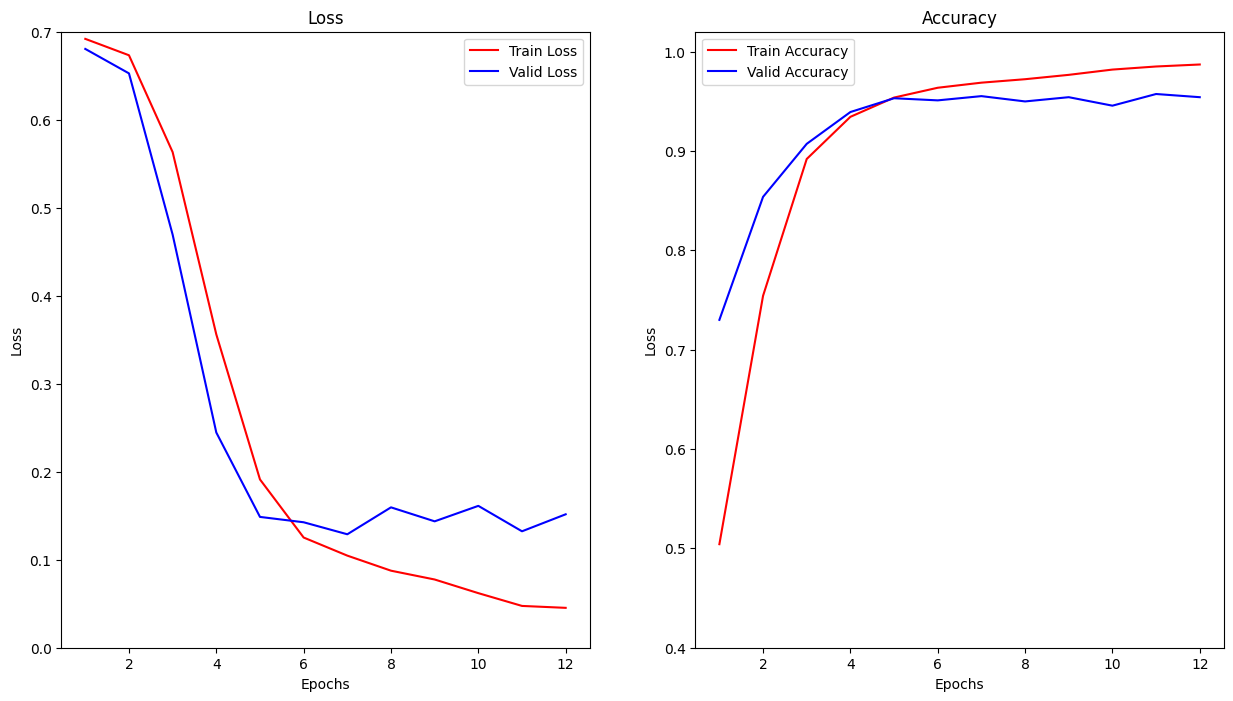

In [56]:
train_loss_history = train_loss_history[train_loss_history != 0]
valid_loss_history = valid_loss_history[valid_loss_history != 0]
train_acc_history = train_acc_history[train_acc_history != 0]

epochs = range(1, len(train_loss_history) + 1)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

axs[0].plot(epochs, train_loss_history, color="red", label="Train Loss")
axs[0].plot(epochs, valid_loss_history, color="blue", label="Valid Loss")
axs[0].set_title("Loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_ylim(0, 0.70)
axs[0].legend()

valid_acc_history = [y["Accuracy"] for y in valid_metrics_history]

axs[1].plot(epochs, train_acc_history, color="red", label="Train Accuracy")
axs[1].plot(epochs, valid_acc_history, color="blue", label="Valid Accuracy")
axs[1].set_title("Accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].set_ylim(0.40, 1.02)
axs[1].legend()

plt.show()

In [57]:
print(len(valid_metrics_history))

clean_metrics_history = [x for x in valid_metrics_history]

df_metrics = pd.DataFrame(clean_metrics_history)

df_metrics = df_metrics[["Accuracy", "Precision", "Recall", "F1-Score"]]

df_metrics.to_csv("metrics_history.csv", index=True)

# visualize metrics result in the table below for each training epoch
df_metrics

12


,Accuracy,Precision,Recall,F1-Score
0,0.729989,0.729989,1.000000,0.843923
1,0.853789,0.982363,0.814327,0.890488
2,0.907150,0.965679,0.904971,0.934340
3,0.939168,0.956332,0.960526,0.958425
4,0.953042,0.965116,0.970760,0.967930
5,0.950907,0.978979,0.953216,0.965926
6,0.955176,0.972059,0.966374,0.969208
7,0.949840,0.946704,0.986842,0.966356
8,0.954109,0.981955,0.954678,0.968125
9,0.945571,0.983206,0.941520,0.961912


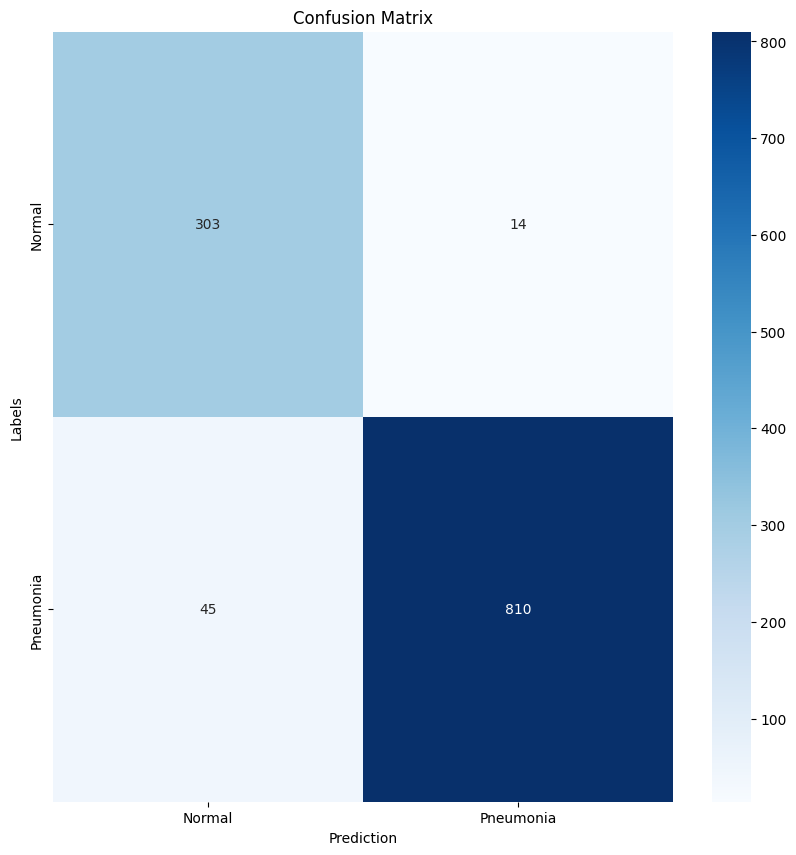

In [58]:
import seaborn as sns

def print_confusion_matrix(cm, title):
    """
        Prints a confusion matrix of the data
    """
    
    classes = ["Normal", "Pneumonia"]
    data = np.array([
        [cm["TN"], cm["FP"]],
        [cm["FN"], cm["TP"]]
    ])
    
    plt.figure(figsize=(10,10))
    sns.heatmap(data, annot=True, fmt='d', xticklabels=classes, cmap="Blues", yticklabels=classes)
    
    plt.ylabel("Labels")
    plt.xlabel("Prediction")
    plt.title(title)
    plt.show()
    
print_confusion_matrix(confusion_m, title="Confusion Matrix")

## Robustness Check

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms


def apply_gaussian_blur(img_tensor, sigma):
    k_size = int(sigma * 3) * 2 + 1
    blur = transforms.GaussianBlur(kernel_size=k_size, sigma=sigma)
    return blur(img_tensor)

def apply_salt_and_pepper(img_tensor, p):
    noisy = img_tensor.clone()
    mask_salt = torch.rand_like(noisy) < (p / 2)
    noisy[mask_salt] = 1.0
    mask_pepper = torch.rand_like(noisy) < (p / 2)
    noisy[mask_pepper] = 0.0
    return noisy

def apply_speckle_noise(img_tensor, sigma):
    noise = torch.randn_like(img_tensor) * sigma
    noisy = img_tensor + img_tensor * noise
    return torch.clamp(noisy, 0, 1)

def robustness_test(model, dataset, class_names, device=device):
    """
    This function choose randomly two images from the test folder, one from the PNEUMONIA
    class and the other from the NORMAL class. Then apply to the image 3 different type of noises
    (Gaussian Blur, Salt-and-pepper, Speckle Noise) for 3 different values of parameters and check if 
    the prediction on the noisy image is correct.
    """
    model.eval()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def denormalize(x):
        return torch.clamp(x * std + mean, 0.0, 1.0)

    def normalize(x):
        return (x - mean) / std

    labels = [dataset[i][1] for i in range(len(dataset))]
    indices_normal = [i for i, y in enumerate(labels) if y == 0] #select the normal indices in the test set
    indices_pneu = [i for i, y in enumerate(labels) if y == 1] # select the pneumonia indices in the test set

    selected_idx = [np.random.choice(indices_normal), np.random.choice(indices_pneu)] #choose one random images per class

    noises = [
        ('Gaussian Blur', [0.2, 0.4, 0.6], apply_gaussian_blur),
        ('Salt-and-Pepper', [0.05, 0.1, 0.15], apply_salt_and_pepper),
        ('Speckle Noise', [0.1, 0.2, 0.3], apply_speckle_noise),
    ]

    for idx in selected_idx:
        img_norm, label = dataset[idx]
        img = denormalize(img_norm.cpu())

        plt.figure(figsize=(15, 12))
        plt.suptitle(f"Robustness fior the class: {class_names[label]}", fontsize=16)

        plot_idx = 1 #subplots counter
        for name, values, func in noises:
            for val in values:
                noisy = func(img, val) #create a noisy image 
                input_tensor = normalize(noisy).unsqueeze(0).to(device) #retransform the image into a normalize one

                with torch.no_grad():
                    output = model(input_tensor) #prediction
                    pred = torch.argmax(output, dim=1).item()

                plt.subplot(3, 3, plot_idx)
                plt.imshow(noisy.permute(1, 2, 0).cpu().numpy())
                plt.title(f"{name} ({val})")
                plt.axis('off')

                real_str = "[1. 0.]" if label == 1 else "[0. 1.]"
                pred_str = "[1. 0.]" if pred == 1 else "[0. 1.]"
                
                #plot the wrong prediction red
                plt.text(
                    0,
                    noisy.shape[1] + 5,
                    f"Real Class: {real_str}\nPredicted Class: {pred_str}",
                    fontsize=10,
                    color='blue' if label == pred else 'red'
                )
                plot_idx += 1

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

robustness_test(model, image_datasets["test"], ["NORMAL", "PNEUMONIA"])

## Folder to save results

In [ ]:
from pathlib import Path
from datetime import datetime
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shutil
from IPython.display import FileLink

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("artifacts") / f"run_{run_tag}"
out_dir.mkdir(parents=True, exist_ok=True)

robustness_saved = []
if "robustness_test" in globals() and "model" in globals() and "image_datasets" in globals() and "test" in image_datasets:
    try:
        original_show = plt.show

        def _save_and_close_show(*args, **kwargs):
            fig = plt.gcf()
            fig_idx = len(robustness_saved) + 1
            fig_path = out_dir / f"robustness_{fig_idx}.png"
            fig.savefig(fig_path, dpi=300, bbox_inches="tight")
            robustness_saved.append(str(fig_path))
            plt.close(fig)

        plt.show = _save_and_close_show
        robustness_test(model, image_datasets["test"], ["NORMAL", "PNEUMONIA"])
        plt.show = original_show
        print(f"Saved robustness plots: {len(robustness_saved)}")
    except Exception as e:
        plt.show = original_show
        print(f"Skipping robustness plot export: {e}")
else:
    print("Skipping robustness plot export: robustness_test/model/image_datasets['test'] not available.")

# ====== 1) Save loss/accuracy plots ======
# Export the training vs validation loss/accuracy chart if histories are available
if "train_loss_history" in globals() and "valid_loss_history" in globals() and "train_acc_history" in globals() and "valid_metrics_history" in globals():
    train_loss_clean = np.array(train_loss_history)[np.array(train_loss_history) != 0]
    valid_loss_clean = np.array(valid_loss_history)[np.array(valid_loss_history) != 0]
    train_acc_clean = np.array(train_acc_history)[np.array(train_acc_history) != 0]
    valid_acc_history = [m["Accuracy"] for m in valid_metrics_history]
    
    min_len = min(len(train_loss_clean), len(valid_loss_clean), len(train_acc_clean), len(valid_acc_history))
    if min_len > 0:
        epochs = range(1, min_len + 1)
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

        axs[0].plot(epochs, train_loss_clean[:min_len], color="red", label="Train Loss")
        axs[0].plot(epochs, valid_loss_clean[:min_len], color="blue", label="Validation Loss")
        axs[0].set_title("Loss")
        axs[0].set_xlabel("Epochs")
        axs[0].set_ylabel("Loss")
        axs[0].legend()

        axs[1].plot(epochs, train_acc_clean[:min_len], color="red", label="Train Accuracy")
        axs[1].plot(epochs, valid_acc_history[:min_len], color="blue", label="Validation Accuracy")
        axs[1].set_title("Accuracy")
        axs[1].set_xlabel("Epochs")
        axs[1].set_ylabel("Accuracy")
        axs[1].legend()

        plot_path = out_dir / "loss_accuracy.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {plot_path}")
    else:
        print("Skipping loss/accuracy plot: empty histories.")
else:
    print("Skipping loss/accuracy plot: required histories not found.")

# ====== 2) Save confusion matrix image ======
if "confusion_m" in globals():
    cm = confusion_m
    classes = ["Normal", "Pneumonia"]
    cm_data = np.array([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]])

    fig_cm = plt.figure(figsize=(8, 8))
    sns.heatmap(cm_data, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap="Blues")
    plt.ylabel("Labels")
    plt.xlabel("Prediction")
    plt.title("Confusion Matrix")
    cm_path = out_dir / "confusion_matrix.png"
    fig_cm.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.close(fig_cm)
    print(f"Saved: {cm_path}")
else:
    print("Skipping confusion matrix image: 'confusion_m' not found.")

# ====== 3) Save metrics history ======
# Save per-epoch validation metrics in both CSV and JSON
if "valid_metrics_history" in globals() and len(valid_metrics_history) > 0:
    df_metrics = pd.DataFrame(valid_metrics_history)
    metrics_cols = [c for c in ["Accuracy", "Precision", "Recall", "F1-Score"] if c in df_metrics.columns]
    if metrics_cols:
        df_metrics = df_metrics[metrics_cols]

    csv_path = out_dir / "metrics_history.csv"
    json_metrics_path = out_dir / "metrics_history.json"
    df_metrics.to_csv(csv_path, index=True)
    df_metrics.to_json(json_metrics_path, orient="records", indent=2)
    print(f"Saved: {csv_path}")
    print(f"Saved: {json_metrics_path}")
else:
    print("Skipping metrics history export: 'valid_metrics_history' not found or empty.")

# Optional: save full training/validation history arrays
history_bundle = {}
if "train_loss_history" in globals(): history_bundle["train_loss_history"] = np.array(train_loss_history).tolist()
if "valid_loss_history" in globals(): history_bundle["valid_loss_history"] = np.array(valid_loss_history).tolist()
if "train_acc_history" in globals(): history_bundle["train_acc_history"] = np.array(train_acc_history).tolist()
if "valid_metrics_history" in globals(): history_bundle["valid_metrics_history"] = valid_metrics_history
if history_bundle:
    history_path = out_dir / "history_bundle.json"
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history_bundle, f, indent=2)
    print(f"Saved: {history_path}")

# ====== 4) Save run parameters JSON ======
# Extract model-level parameters when available (SNN threshold and beta)
vthreshold = None
beta = None
if "model" in globals() and hasattr(model, "snn") and hasattr(model.snn, "lif1"):
    lif = model.snn.lif1
    if hasattr(lif, "threshold"):
        t = lif.threshold
        vthreshold = float(t.item()) if hasattr(t, "item") else float(t)
    if hasattr(lif, "beta"):
        b = lif.beta
        beta = float(b.item()) if hasattr(b, "item") else float(b)

tc = globals().get("target_count", None)
params = {
    "lr": float(lr) if "lr" in globals() else None,
    "weight_decay": float(w_decay) if "w_decay" in globals() else None,
    "Vthreshold": vthreshold,
    "beta": beta,
    "target_count": int(tc) if tc is not None else None
}

params_path = out_dir / "run_params.json"
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(params, f, indent=2)
print(f"Saved: {params_path}")

if robustness_saved:
    print("Robustness files:")
    for p in robustness_saved:
        print(f"- {p}")

print(f"\nAll artifacts saved in: {out_dir.resolve()}")

# ====== 5) Create ZIP for Kaggle/Colab download ======
zip_name = f"results_{run_tag}"
zip_path = Path(f"{zip_name}.zip")

try:
    # Compress only the current run folder into a zip archive
    # shutil.make_archive(base_name, format, root_dir)
    shutil.make_archive(zip_name, 'zip', out_dir)
    
    print("-" * 30)
    print(f"📦 Archive created: {zip_path.name}")
    print(f"📂 Content: all files from {out_dir.name}")
    
    # Generate a clickable file link in Jupyter/Kaggle/Colab
    display(FileLink(zip_path.name))
    print("-" * 30)
    
except Exception as e:
    print(f"Error while creating ZIP archive: {e}")